# RNN & LSTM with Attention for Explainability

This notebook focuses specifically on Recurrent Neural Network (RNN) architectures (GRU and LSTM) and adds an attention mechanism for explainability. You can run this directly in Colab.

In [1]:
# Colab bootstrap: clone or update the repo, then run from its root.
from pathlib import Path
import os
import subprocess

REPO_URL = "https://github.com/vibhor-5/btp.git"
REPO_DIR = Path("/content/btp")
try:
    import google.colab  # type: ignore  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not REPO_DIR.exists():
        subprocess.run(["git", "clone", REPO_URL, str(REPO_DIR)], check=True)
    else:
        subprocess.run(["git", "-C", str(REPO_DIR), "pull", "--ff-only"], check=True)
    os.chdir(REPO_DIR)
else:
    os.chdir(Path.cwd())

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "top15_train.parquet"
TEST_PATH = DATA_DIR / "top15_test.parquet"

try:
    import pyarrow  # noqa: F401
except ImportError:
    !pip -q install pyarrow

from dataclasses import dataclass
from typing import Dict, List, Tuple
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, average_precision_score, brier_score_loss, f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

OUTPUT_DIR = PROJECT_ROOT / "outputs"
CKPT_DIR = OUTPUT_DIR / "checkpoints"
OUTPUT_DIR.mkdir(exist_ok=True)
CKPT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
@dataclass
class Config:
    history_len: int = 28
    forecast_len: int = 7
    val_days: int = 15
    batch_size: int = 256
    epochs: int = 10
    lr: float = 1e-3
    weight_decay: float = 1e-4
    hidden_dim: int = 128
    embed_dim: int = 32
    num_layers: int = 2
    dropout: float = 0.2
    patience: int = 4
    seed: int = 42
    use_pos_weight: bool = True

CFG = Config()

STATIC_CAT_COLS = ["city_id", "store_id", "management_group_id", "first_category_id", "second_category_id", "third_category_id", "product_id"]
TEMPORAL_CAT_COLS = ["holiday_flag", "activity_flag"]
CAT_COLS = STATIC_CAT_COLS + TEMPORAL_CAT_COLS
HIST_NUM_COLS = ["discount", "precpt", "avg_temperature", "avg_humidity", "avg_wind_level", "sale_amount", "stockout", "stockout_streak", "stockout_rolling_7", "sale_amount_lag1"]
FUTURE_NUM_COLS = ["discount", "precpt", "avg_temperature", "avg_humidity", "avg_wind_level"]
TARGET_COL = "stockout"

def seed_everything(seed: int):
    import random, numpy as np, torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(CFG.seed)
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## Data Loading and Pipeline

In [3]:
class CategoryEncoder:
    def __init__(self, cols: List[str]):
        self.cols = cols
        self.maps: Dict[str, Dict[str, int]] = {}
        self.sizes: Dict[str, int] = {}

    def fit(self, df: pd.DataFrame):
        for col in self.cols:
            values = df[col].fillna("__NA__").astype(str).unique().tolist()
            mapping = {"__UNK__": 0}
            mapping.update({v: i + 1 for i, v in enumerate(sorted(values))})
            self.maps[col] = mapping
            self.sizes[col] = len(mapping)
        return self

    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        for col in self.cols:
            mapping = self.maps[col]
            out[col] = out[col].fillna("__NA__").astype(str).map(mapping).fillna(0).astype(np.int64)
        return out

def load_data():
    train = pd.read_parquet(DATA_DIR / "top15_train.parquet")
    test = pd.read_parquet(DATA_DIR / "top15_test.parquet")
    for df in (train, test):
        df["dt"] = pd.to_datetime(df["dt"])
        df[TARGET_COL] = (df["stock_hour6_22_cnt"] > 0).astype(np.float32)
    return train, test

def split_dates(train_df: pd.DataFrame, val_days: int):
    dates = np.array(sorted(train_df["dt"].unique()))
    val_start = pd.Timestamp(dates[-val_days])
    train_end = pd.Timestamp(dates[-val_days - 1])
    return train_end, val_start

def add_engineered_features(df):
    df = df.sort_values(["store_id", "product_id", "dt"]).reset_index(drop=True)
    def streak(s):
        groups = (s != s.shift()).cumsum()
        return s.groupby(groups).cumcount() + 1
    df["stockout_streak"] = df.groupby(["store_id", "product_id"])[TARGET_COL].transform(streak)
    df.loc[df[TARGET_COL] == 0, "stockout_streak"] = 0
    df["stockout_rolling_7"] = df.groupby(["store_id", "product_id"])[TARGET_COL].transform(lambda x: x.rolling(7, min_periods=1).mean())
    df["sale_amount_lag1"] = df.groupby(["store_id", "product_id"])["sale_amount"].shift(1).fillna(0)
    return df

def fit_apply_preprocessors(train_df, test_df, train_end):
    combined = pd.concat([train_df.assign(source="train"), test_df.assign(source="test")], ignore_index=True)
    combined = add_engineered_features(combined)
    fit_rows = combined[(combined["source"] == "train") & (combined["dt"] <= train_end)].copy()
    cat_encoder = CategoryEncoder(CAT_COLS).fit(fit_rows)
    scale_cols = sorted((set(HIST_NUM_COLS + FUTURE_NUM_COLS) - {TARGET_COL}))
    scaler = StandardScaler().fit(fit_rows[scale_cols].fillna(0.0))
    combined = cat_encoder.transform(combined)
    combined[scale_cols] = scaler.transform(combined[scale_cols].fillna(0.0))
    return combined, cat_encoder

def make_windows(df: pd.DataFrame, cfg: Config, train_df: pd.DataFrame, train_end: pd.Timestamp, val_start: pd.Timestamp):
    rows = []
    train_max = train_df["dt"].max()
    df = df.sort_values(["store_id", "product_id", "dt"]).reset_index(drop=True)
    for _, group in df.groupby(["store_id", "product_id"], sort=False):
        group = group.sort_values("dt")
        if len(group) < cfg.history_len + cfg.forecast_len:
            continue
        hist_num = group[HIST_NUM_COLS].to_numpy(np.float32)
        fut_num = group[FUTURE_NUM_COLS].to_numpy(np.float32)
        cats = group[CAT_COLS].to_numpy(np.int64)
        target = group[TARGET_COL].to_numpy(np.float32)
        dates = group["dt"].to_numpy()
        for start in range(0, len(group) - cfg.history_len - cfg.forecast_len + 1):
            hist_end = start + cfg.history_len
            fut_end = hist_end + cfg.forecast_len
            target_start = pd.Timestamp(dates[hist_end])
            target_end = pd.Timestamp(dates[fut_end - 1])
            if target_end <= train_end:
                split = "train"
            elif target_start >= val_start and target_end <= train_max:
                split = "val"
            elif target_start > train_max:
                split = "test"
            else:
                continue
            rows.append({"hist_num": hist_num[start:hist_end], "hist_cat": cats[start:hist_end], "future_num": fut_num[hist_end:fut_end], "future_cat": cats[hist_end:fut_end], "target": target[hist_end:fut_end], "split": split})
    return rows

class StockoutSequenceDataset(Dataset):
    def __init__(self, windows, split: str):
        self.windows = [w for w in windows if w["split"] == split]
    def __len__(self):
        return len(self.windows)
    def __getitem__(self, idx):
        w = self.windows[idx]
        return {
            "hist_num": torch.tensor(w["hist_num"], dtype=torch.float32),
            "hist_cat": torch.tensor(w["hist_cat"], dtype=torch.long),
            "future_num": torch.tensor(w["future_num"], dtype=torch.float32),
            "future_cat": torch.tensor(w["future_cat"], dtype=torch.long),
            "target": torch.tensor(w["target"], dtype=torch.float32),
        }

train_df, test_df = load_data()
train_end, val_start = split_dates(train_df, CFG.val_days)
encoded, cat_encoder = fit_apply_preprocessors(train_df, test_df, train_end)
windows = make_windows(encoded, CFG, train_df, train_end, val_start)
datasets = {s: StockoutSequenceDataset(windows, s) for s in ["train", "val", "test"]}
loaders = {"train": DataLoader(datasets["train"], CFG.batch_size, shuffle=True), "val": DataLoader(datasets["val"], CFG.batch_size, shuffle=False), "test": DataLoader(datasets["test"], CFG.batch_size, shuffle=False)}
print({s: len(ds) for s, ds in datasets.items()})

{'train': 60866, 'val': 21069, 'test': 21069}


## RNN Models with Attention

In [4]:
class CatEmbedder(nn.Module):
    def __init__(self, cat_sizes: List[int], embed_dim: int):
        super().__init__()
        self.embeddings = nn.ModuleList([nn.Embedding(size, embed_dim) for size in cat_sizes])
        self.out_dim = len(cat_sizes) * embed_dim
    def forward(self, x_cat):
        return torch.cat([emb(x_cat[..., i]) for i, emb in enumerate(self.embeddings)], dim=-1)

class RNNSeq2Seq(nn.Module):
    """Standard GRU or LSTM Seq2Seq model (Encoder-Decoder)"""
    def __init__(self, hist_num_dim, future_num_dim, cat_sizes, cfg: Config, cell="gru"):
        super().__init__()
        self.cat_embed = CatEmbedder(cat_sizes, cfg.embed_dim)
        rnn_cls = nn.GRU if cell == "gru" else nn.LSTM
        hist_in = hist_num_dim + self.cat_embed.out_dim
        fut_in = future_num_dim + self.cat_embed.out_dim
        self.encoder = rnn_cls(hist_in, cfg.hidden_dim, cfg.num_layers, batch_first=True, dropout=cfg.dropout if cfg.num_layers > 1 else 0)
        self.decoder = rnn_cls(fut_in, cfg.hidden_dim, cfg.num_layers, batch_first=True, dropout=cfg.dropout if cfg.num_layers > 1 else 0)
        self.head = nn.Linear(cfg.hidden_dim, 1)
        self.cell = cell
    def forward(self, batch):
        hcat = self.cat_embed(batch["hist_cat"])
        fcat = self.cat_embed(batch["future_cat"])
        enc_in = torch.cat([batch["hist_num"], hcat], dim=-1)
        dec_in = torch.cat([batch["future_num"], fcat], dim=-1)

        _, state = self.encoder(enc_in)
        out, _ = self.decoder(dec_in, state)
        return self.head(out).squeeze(-1)

class AttentionBlock(nn.Module):
    """Calculates attention weights over encoder outputs."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim * 2, hidden_dim)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, dec_hidden, enc_outputs):
        # dec_hidden: [batch_size, hidden_dim]
        # enc_outputs: [batch_size, seq_len, hidden_dim]
        seq_len = enc_outputs.size(1)

        # Repeat decoder hidden state for each time step of the encoder
        dec_hidden_repeated = dec_hidden.unsqueeze(1).repeat(1, seq_len, 1)

        # Calculate attention energy
        energy = torch.tanh(self.attn(torch.cat((dec_hidden_repeated, enc_outputs), dim=2)))
        attention_weights = F.softmax(self.v(energy).squeeze(2), dim=1)

        # Context vector
        context = torch.bmm(attention_weights.unsqueeze(1), enc_outputs) # [batch_size, 1, hidden_dim]

        return context, attention_weights

class RNNAttentionSeq2Seq(nn.Module):
    """RNN Encoder-Decoder with Attention for Explainability"""
    def __init__(self, hist_num_dim, future_num_dim, cat_sizes, cfg: Config, cell="lstm"):
        super().__init__()
        self.cat_embed = CatEmbedder(cat_sizes, cfg.embed_dim)
        rnn_cls = nn.GRU if cell == "gru" else nn.LSTM
        hist_in = hist_num_dim + self.cat_embed.out_dim
        fut_in = future_num_dim + self.cat_embed.out_dim

        self.encoder = rnn_cls(hist_in, cfg.hidden_dim, cfg.num_layers, batch_first=True, dropout=cfg.dropout if cfg.num_layers > 1 else 0, bidirectional=True)
        self.decoder = rnn_cls(fut_in, cfg.hidden_dim * 2, cfg.num_layers, batch_first=True, dropout=cfg.dropout if cfg.num_layers > 1 else 0)

        self.attention = AttentionBlock(cfg.hidden_dim * 2)

        # Final prediction uses context + decoder output
        self.head = nn.Linear(cfg.hidden_dim * 4, 1)
        self.cell = cell
        self.num_layers = cfg.num_layers

    def forward(self, batch, return_attention=False):
        hcat = self.cat_embed(batch["hist_cat"])
        fcat = self.cat_embed(batch["future_cat"])
        enc_in = torch.cat([batch["hist_num"], hcat], dim=-1)
        dec_in = torch.cat([batch["future_num"], fcat], dim=-1)

        # Encode history
        enc_out, state = self.encoder(enc_in)

        # Prepare initial state for decoder
        if self.cell == "lstm":
            h_n, c_n = state
            h_n = h_n.view(self.num_layers, 2, -1, h_n.size(-1)).transpose(1, 2).contiguous().view(self.num_layers, -1, h_n.size(-1)*2)
            c_n = c_n.view(self.num_layers, 2, -1, c_n.size(-1)).transpose(1, 2).contiguous().view(self.num_layers, -1, c_n.size(-1)*2)
            dec_state = (h_n, c_n)
        else:
            h_n = state.view(self.num_layers, 2, -1, state.size(-1)).transpose(1, 2).contiguous().view(self.num_layers, -1, state.size(-1)*2)
            dec_state = h_n

        # Decode step-by-step to apply attention
        batch_size = enc_out.size(0)
        forecast_len = dec_in.size(1)

        outputs = []
        attn_weights_list = []

        for t in range(forecast_len):
            dec_in_step = dec_in[:, t:t+1, :]
            dec_out_step, dec_state = self.decoder(dec_in_step, dec_state)

            if self.cell == "lstm":
                hidden = dec_state[0][-1] # Get top layer hidden state
            else:
                hidden = dec_state[-1]

            context, attn_weights = self.attention(hidden, enc_out)
            attn_weights_list.append(attn_weights)

            # Combine decoder output and context for prediction
            pred_in = torch.cat((dec_out_step.squeeze(1), context.squeeze(1)), dim=1)
            outputs.append(self.head(pred_in))

        outputs = torch.stack(outputs, dim=1).squeeze(-1)

        if return_attention:
            return outputs, torch.stack(attn_weights_list, dim=1)
        return outputs

cat_sizes = [cat_encoder.sizes[c] for c in CAT_COLS]
hist_num_dim = len(HIST_NUM_COLS)
future_num_dim = len(FUTURE_NUM_COLS)


class BiRNNSeq2Seq(nn.Module):
    def __init__(self, rnn_type="lstm"):
        super().__init__()
        self.cat_embed = CatEmbedder([cat_encoder.sizes[c] for c in CAT_COLS], CFG.embed_dim)

        hist_input_dim = len(HIST_NUM_COLS) + self.cat_embed.out_dim
        future_input_dim = len(FUTURE_NUM_COLS) + self.cat_embed.out_dim

        rnn_cls = nn.LSTM if rnn_type == "lstm" else nn.GRU
        self.encoder = rnn_cls(hist_input_dim, CFG.hidden_dim, num_layers=CFG.num_layers,
                               batch_first=True, dropout=CFG.dropout, bidirectional=True)
        self.decoder = rnn_cls(future_input_dim, CFG.hidden_dim, num_layers=CFG.num_layers,
                               batch_first=True, dropout=CFG.dropout, bidirectional=True)

        self.fc = nn.Linear(CFG.hidden_dim * 2, 1)  # * 2 because bidirectional

    def forward(self, batch):
        hist_num = batch["hist_num"]
        hist_cat = self.cat_embed(batch["hist_cat"])
        hist_feat = torch.cat([hist_num, hist_cat], dim=-1)

        future_num = batch["future_num"]
        future_cat = self.cat_embed(batch["future_cat"])
        future_feat = torch.cat([future_num, future_cat], dim=-1)

        _, hidden = self.encoder(hist_feat)

        dec_out, _ = self.decoder(future_feat, hidden)

        out = self.fc(dec_out).squeeze(-1)
        return out

class CNN_LSTM_Seq2Seq(nn.Module):
    def __init__(self):
        super().__init__()
        self.cat_embed = CatEmbedder([cat_encoder.sizes[c] for c in CAT_COLS], CFG.embed_dim)

        hist_input_dim = len(HIST_NUM_COLS) + self.cat_embed.out_dim
        future_input_dim = len(FUTURE_NUM_COLS) + self.cat_embed.out_dim

        # 1D CNN to extract local temporal features (kernel size 3)
        self.conv1d = nn.Conv1d(in_channels=hist_input_dim, out_channels=CFG.hidden_dim, kernel_size=3, padding=1)
        self.relu = nn.ReLU()

        self.encoder = nn.LSTM(CFG.hidden_dim, CFG.hidden_dim, num_layers=CFG.num_layers,
                               batch_first=True, dropout=CFG.dropout)
        self.decoder = nn.LSTM(future_input_dim, CFG.hidden_dim, num_layers=CFG.num_layers,
                               batch_first=True, dropout=CFG.dropout)

        self.fc = nn.Linear(CFG.hidden_dim, 1)

    def forward(self, batch):
        hist_num = batch["hist_num"]
        hist_cat = self.cat_embed(batch["hist_cat"])
        hist_feat = torch.cat([hist_num, hist_cat], dim=-1)

        # CNN expects (batch, channels, seq_len)
        hist_feat = hist_feat.transpose(1, 2)
        conv_feat = self.relu(self.conv1d(hist_feat))
        conv_feat = conv_feat.transpose(1, 2)  # back to (batch, seq_len, channels)

        _, hidden = self.encoder(conv_feat)

        future_num = batch["future_num"]
        future_cat = self.cat_embed(batch["future_cat"])
        future_feat = torch.cat([future_num, future_cat], dim=-1)

        dec_out, _ = self.decoder(future_feat, hidden)

        out = self.fc(dec_out).squeeze(-1)
        return out

cat_sizes = [cat_encoder.sizes[c] for c in CAT_COLS]
model_factories = {
    "lstm_seq2seq": lambda: RNNSeq2Seq(len(HIST_NUM_COLS), len(FUTURE_NUM_COLS), cat_sizes, CFG, "lstm"),
    "gru_seq2seq": lambda: RNNSeq2Seq(len(HIST_NUM_COLS), len(FUTURE_NUM_COLS), cat_sizes, CFG, "gru"),
    "bilstm_seq2seq": lambda: BiRNNSeq2Seq("lstm"),
    "cnn_lstm_seq2seq": lambda: CNN_LSTM_Seq2Seq(),
    "gru_attention": lambda: RNNAttentionSeq2Seq(len(HIST_NUM_COLS), len(FUTURE_NUM_COLS), cat_sizes, CFG, "gru"),
    "lstm_attention": lambda: RNNAttentionSeq2Seq(len(HIST_NUM_COLS), len(FUTURE_NUM_COLS), cat_sizes, CFG, "lstm")
}


for name, factory in model_factories.items():
    m = factory().to(device)
    batch = next(iter(loaders["train"]))
    with torch.no_grad():
        if "attention" in name:
            out, attn = m({k: v.to(device) for k, v in batch.items()}, return_attention=True)
            print(name, out.shape, "Attn shape:", attn.shape)
        else:
            out = m({k: v.to(device) for k, v in batch.items()})
            print(name, out.shape)

lstm_seq2seq torch.Size([256, 7])
gru_seq2seq torch.Size([256, 7])
bilstm_seq2seq torch.Size([256, 7])
cnn_lstm_seq2seq torch.Size([256, 7])
gru_attention torch.Size([256, 7]) Attn shape: torch.Size([256, 7, 28])
lstm_attention torch.Size([256, 7]) Attn shape: torch.Size([256, 7, 28])


## Training Loop and Evaluation

In [5]:
def metric_dict(y_true, y_prob, prefix=""):
    y_true = np.asarray(y_true).reshape(-1)
    y_prob = np.asarray(y_prob).reshape(-1)
    y_pred = (y_prob >= 0.5).astype(int)
    out = {}
    if len(np.unique(y_true)) > 1:
        out[prefix + "roc_auc"] = roc_auc_score(y_true, y_prob)
        out[prefix + "pr_auc"] = average_precision_score(y_true, y_prob)
    else:
        out[prefix + "roc_auc"] = np.nan
        out[prefix + "pr_auc"] = np.nan
    out[prefix + "accuracy"] = accuracy_score(y_true, y_pred)
    out[prefix + "f1"] = f1_score(y_true, y_pred, zero_division=0)
    out[prefix + "precision"] = precision_score(y_true, y_pred, zero_division=0)
    out[prefix + "recall"] = recall_score(y_true, y_pred, zero_division=0)
    out[prefix + "brier"] = brier_score_loss(y_true, y_prob)
    return out

def train_model(model_name: str, model: nn.Module, loaders: dict, cfg: Config):
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")

    # Calculate positive weight for imbalanced dataset
    if cfg.use_pos_weight:
        train_targets = []
        for batch in loaders["train"]:
            train_targets.append(batch["target"].view(-1))
        train_targets = torch.cat(train_targets)
        pos_count = train_targets.sum().item()
        neg_count = len(train_targets) - pos_count
        pos_weight = torch.tensor([neg_count / max(1, pos_count)], device=device)
    else:
        pos_weight = None

    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_pr = -1
    best_epoch = -1
    epochs_no_improve = 0

    for epoch in range(cfg.epochs):
        model.train()
        train_losses = []
        for batch in loaders["train"]:
            batch = {k: v.to(device) for k, v in batch.items()}
            optimizer.zero_grad()
            with torch.cuda.amp.autocast(enabled=device.type == "cuda"):
                if "attention" in model_name:
                    logits = model(batch, return_attention=False)
                else:
                    logits = model(batch)
                loss = criterion(logits, batch["target"])
            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            train_losses.append(loss.item())

        model.eval()
        val_probs, val_targets = [], []
        with torch.no_grad():
            for batch in loaders["val"]:
                batch = {k: v.to(device) for k, v in batch.items()}
                if "attention" in model_name:
                    logits = model(batch, return_attention=False)
                else:
                    logits = model(batch)
                val_probs.append(torch.sigmoid(logits).cpu().numpy())
                val_targets.append(batch["target"].cpu().numpy())

        val_probs = np.concatenate(val_probs)
        val_targets = np.concatenate(val_targets)
        metrics = metric_dict(val_targets, val_probs)
        val_pr = metrics["pr_auc"]

        print(f"[{model_name}] Epoch {epoch+1}/{cfg.epochs} | Train Loss: {np.mean(train_losses):.4f} | Val PR-AUC: {val_pr:.4f} | Val ROC-AUC: {metrics['roc_auc']:.4f}")

        if val_pr > best_val_pr:
            best_val_pr = val_pr
            best_epoch = epoch
            epochs_no_improve = 0
            torch.save({"model_state": model.state_dict(), "config": cfg, "cat_sizes": cat_sizes}, CKPT_DIR / f"{model_name}.pt")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= cfg.patience:
                print(f"Early stopping triggered.")
                break

    # Load best model and evaluate on test
    model.load_state_dict(torch.load(CKPT_DIR / f"{model_name}.pt", weights_only=False)["model_state"])
    model.eval()
    test_probs, test_targets = [], []
    with torch.no_grad():
        for batch in loaders["test"]:
            batch = {k: v.to(device) for k, v in batch.items()}
            if "attention" in model_name:
                logits = model(batch, return_attention=False)
            else:
                logits = model(batch)
            test_probs.append(torch.sigmoid(logits).cpu().numpy())
            test_targets.append(batch["target"].cpu().numpy())

    test_probs = np.concatenate(test_probs)
    test_targets = np.concatenate(test_targets)
    test_metrics = metric_dict(test_targets, test_probs)
    print(f"[{model_name}] TEST PR-AUC: {test_metrics['pr_auc']:.4f} | TEST F1: {test_metrics['f1']:.4f} | TEST ROC-AUC: {test_metrics['roc_auc']:.4f}\n")
    return test_metrics

all_metrics = {}
for name in model_factories.keys():
    model = model_factories[name]().to(device)
    all_metrics[name] = train_model(name, model, loaders, CFG)

/tmp/ipykernel_599/2991219297.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=device.type == "cuda")
/tmp/ipykernel_599/2991219297.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


[lstm_seq2seq] Epoch 1/10 | Train Loss: 0.5601 | Val PR-AUC: 0.4698 | Val ROC-AUC: 0.5734


/tmp/ipykernel_599/2991219297.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


[lstm_seq2seq] Epoch 2/10 | Train Loss: 0.5275 | Val PR-AUC: 0.4763 | Val ROC-AUC: 0.5696


/tmp/ipykernel_599/2991219297.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


...

[lstm_attention] Epoch 8/10 | Train Loss: 0.4261 | Val PR-AUC: 0.4547 | Val ROC-AUC: 0.5517


/tmp/ipykernel_599/2991219297.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


[lstm_attention] Epoch 9/10 | Train Loss: 0.4050 | Val PR-AUC: 0.4619 | Val ROC-AUC: 0.5543


/tmp/ipykernel_599/2991219297.py:47: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=device.type == "cuda"):


[lstm_attention] Epoch 10/10 | Train Loss: 0.3823 | Val PR-AUC: 0.4595 | Val ROC-AUC: 0.5554
[lstm_attention] TEST PR-AUC: 0.4984 | TEST F1: 0.4272 | TEST ROC-AUC: 0.5236



## Explainability: Visualizing Attention

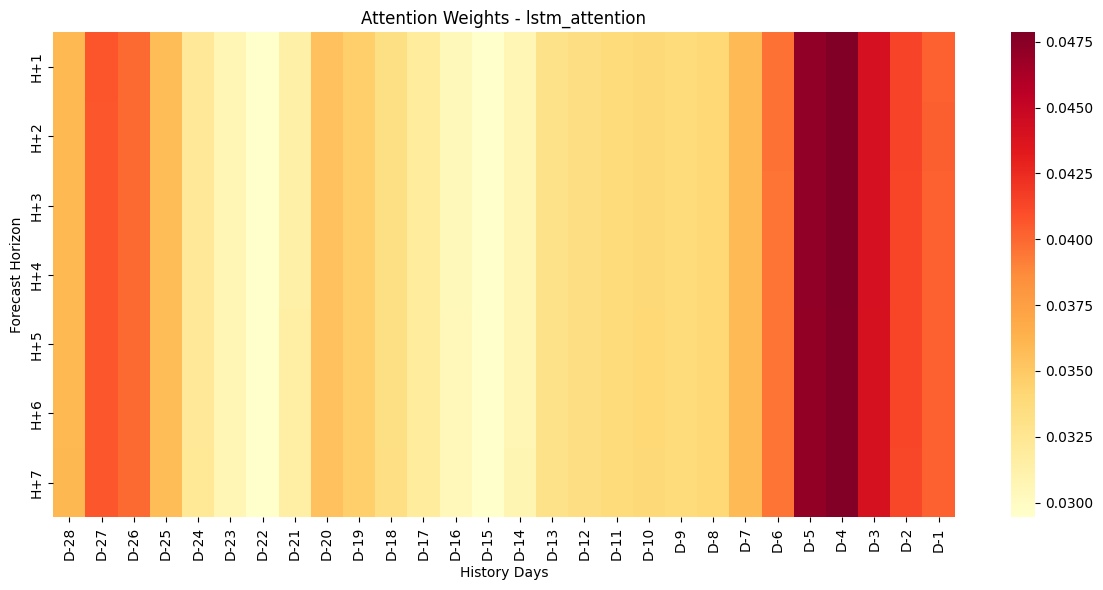

In [6]:
def plot_attention(model_name="lstm_attention", sample_idx=0):
    # Load model
    model = model_factories[model_name]().to(device)
    model.load_state_dict(torch.load(CKPT_DIR / f"{model_name}.pt", weights_only=False)["model_state"])
    model.eval()

    # Get one batch from test set
    batch = next(iter(loaders["test"]))
    with torch.no_grad():
        out, attn = model({k: v.to(device) for k, v in batch.items()}, return_attention=True)

    attn_np = attn[sample_idx].cpu().numpy() # [forecast_len, history_len]

    plt.figure(figsize=(12, 6))
    sns.heatmap(attn_np, cmap="YlOrRd",
                xticklabels=[f"D-{CFG.history_len - i}" for i in range(CFG.history_len)],
                yticklabels=[f"H+{i+1}" for i in range(CFG.forecast_len)])
    plt.xlabel("History Days")
    plt.ylabel("Forecast Horizon")
    plt.title(f"Attention Weights - {model_name}")
    plt.tight_layout()
    plt.show()

# Visualize attention for the LSTM with attention model
plot_attention("lstm_attention", sample_idx=5)

## Advanced Explainability: Feature Importance with Captum (Integrated Gradients)
Attention shows us *when* the model is looking, but Integrated Gradients tells us *which features* (temperature, sales, streak) are driving the stockout prediction at those times.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 34.3 MB/s eta 0:00:00


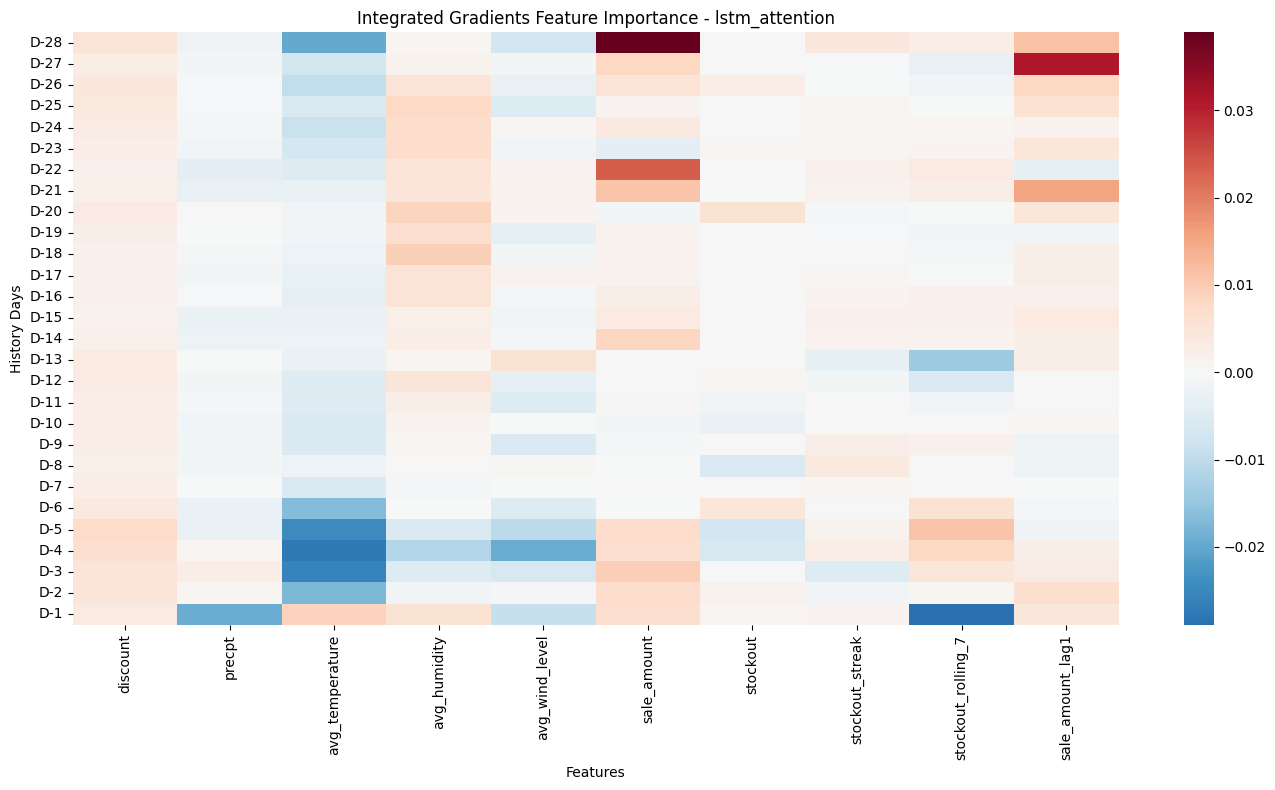

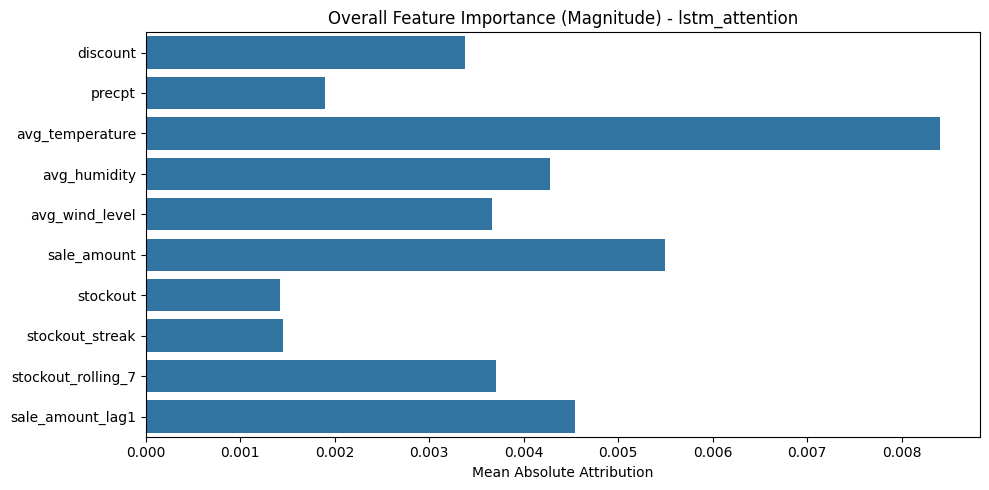

In [7]:
!pip install -q captum
from captum.attr import IntegratedGradients
import matplotlib.pyplot as plt
import seaborn as sns

class ModelIGWrapper(nn.Module):
    def __init__(self, model, model_name):
        super().__init__()
        self.model = model
        self.model_name = model_name

    def forward(self, hist_num, hist_cat, future_num, future_cat):
        batch = {
            "hist_num": hist_num,
            "hist_cat": hist_cat.long(),
            "future_num": future_num,
            "future_cat": future_cat.long()
        }
        if "attention" in self.model_name:
            out = self.model(batch, return_attention=False)
        else:
            out = self.model(batch)
        return out.mean(dim=1, keepdim=True)  # Avg over 7 days

def plot_integrated_gradients(model_name="lstm_attention", sample_idx=0):
    model = model_factories[model_name]().to(device)
    model.load_state_dict(torch.load(CKPT_DIR / f"{model_name}.pt", weights_only=False)["model_state"])
    model.eval()

    batch = next(iter(loaders["test"]))
    batch = {k: v.to(device) for k, v in batch.items()}

    wrapper = ModelIGWrapper(model, model_name)
    ig = IntegratedGradients(wrapper)

    hist_num = batch["hist_num"][sample_idx:sample_idx+1].requires_grad_()
    hist_cat = batch["hist_cat"][sample_idx:sample_idx+1]
    future_num = batch["future_num"][sample_idx:sample_idx+1]
    future_cat = batch["future_cat"][sample_idx:sample_idx+1]

    # We attribute only to hist_num for simplicity
    with torch.backends.cudnn.flags(enabled=False):
        attributions, delta = ig.attribute(inputs=hist_num,
                                           additional_forward_args=(hist_cat, future_num, future_cat),
                                           target=0, return_convergence_delta=True)

    attr_np = attributions.squeeze(0).cpu().detach().numpy()

    plt.figure(figsize=(14, 8))
    sns.heatmap(attr_np, cmap="RdBu_r", center=0,
                xticklabels=HIST_NUM_COLS,
                yticklabels=[f"D-{CFG.history_len - i}" for i in range(CFG.history_len)])
    plt.title(f"Integrated Gradients Feature Importance - {model_name}")
    plt.xlabel("Features")
    plt.ylabel("History Days")
    plt.tight_layout()
    plt.show()

    agg_attr = np.abs(attr_np).mean(axis=0)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=agg_attr, y=HIST_NUM_COLS)
    plt.title(f"Overall Feature Importance (Magnitude) - {model_name}")
    plt.xlabel("Mean Absolute Attribution")
    plt.tight_layout()
    plt.show()

plot_integrated_gradients("lstm_attention", sample_idx=5)


## Advanced Explainability: SHAP (SHapley Additive exPlanations)
We can also use SHAP's DeepExplainer on the PyTorch model to get global feature importance distributions.

In [8]:
!pip install -q shap
import shap

def plot_shap(model_name="lstm_attention"):
    model = model_factories[model_name]().to(device)
    model.load_state_dict(torch.load(CKPT_DIR / f"{model_name}.pt", weights_only=False)["model_state"])
    model.eval()

    wrapper = ModelIGWrapper(model, model_name)

    # 1. Prepare background data for DeepExplainer
    bg_batch = next(iter(loaders["train"]))
    bg_num = bg_batch["hist_num"][:50].to(device)  # 50 samples for background
    bg_cat = bg_batch["hist_cat"][:50].to(device)
    bg_f_num = bg_batch["future_num"][:50].to(device)
    bg_f_cat = bg_batch["future_cat"][:50].to(device)

    # We need to wrap it so it only takes 1 tensor input for SHAP's DeepExplainer
    class SingleInputWrapper(nn.Module):
        def __init__(self, wrapper_model, hist_cat, future_num, future_cat):
            super().__init__()
            self.wrapper_model = wrapper_model
            self.hist_cat = hist_cat
            self.future_num = future_num
            self.future_cat = future_cat
        def forward(self, hist_num):
            # Repeat the static/categorical features to match batch size of hist_num
            b = hist_num.shape[0]
            return self.wrapper_model(hist_num, self.hist_cat[:b], self.future_num[:b], self.future_cat[:b])

    # 2. Test data
    test_batch = next(iter(loaders["test"]))
    test_num = test_batch["hist_num"][:20].to(device)

    shap_model = SingleInputWrapper(wrapper, test_batch["hist_cat"].to(device), test_batch["future_num"].to(device), test_batch["future_cat"].to(device))

    # 3. Create explainer
    explainer = shap.DeepExplainer(shap_model, bg_num)
    shap_values = explainer.shap_values(test_num)

    # Reshape for plotting
    shap_values_flat = shap_values.reshape(test_num.shape[0], -1)
    test_num_flat = test_num.cpu().numpy().reshape(test_num.shape[0], -1)

    feature_names = []
    for d in range(CFG.history_len):
        for col in HIST_NUM_COLS:
            feature_names.append(f"D-{CFG.history_len-d}_{col}")

    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values_flat, test_num_flat, feature_names=feature_names, max_display=15)

plot_shap("lstm_attention")


RuntimeError: cudnn RNN backward can only be called in training mode